# Clustering Benchmark Results Summary

Load all CSV results from Python and R benchmarks.

In [1]:
import numpy as np
import os
import glob

# Import pandas library for data manipulation and analysis
import pandas as pd
# Import matplotlib.pyplot for creating the figure and subplots
import matplotlib.pyplot as plt
# Import seaborn library for advanced statistical plotting and styling
import seaborn as sns
# Import the ticker module to format axis ticks (e.g., plain numbers on log scale)
import matplotlib.ticker as ticker
# Import Line2D to manually construct custom legend handles
from matplotlib.lines import Line2D

In [2]:
# Define the relative path to your results directory
results_folder = 'results'
# Retrieve all CSV files in the specified folder
file_paths = glob.glob(f"{results_folder}/*.csv")

# Initialize an empty list to store DataFrames
df_list = []

# Loop through each found file path to process and standardize the data
for file_path in file_paths:
    df = pd.read_csv(file_path)
    
    base_name = os.path.basename(file_path)
    clean_name = base_name.replace('_results.csv', '')
    name_parts = clean_name.split('_')
    
    language = name_parts[0]
    algorithm = name_parts[1]
    
    if len(name_parts) > 2:
        hardware = name_parts[2]
    else:
        hardware = 'cpu'
        
    # Determine the specific library based on language and hardware combinations
    if language.lower() == 'python':
        if hardware.lower() == 'gpu':
            library = 'cuML'
        else:
            library = 'sklearn'
    elif language.lower() == 'r':
        library = 'R'
    else:
        library = language.upper()
        
    df['Algorithm'] = algorithm.upper()
    df['Library'] = library
    
    # Unify metric column names
    rename_mapping = {}
    for col in df.columns:
        if col.endswith('Runtime_sec'):
            rename_mapping[col] = 'Runtime_sec'
        elif col.endswith('ARI'):
            rename_mapping[col] = 'ARI'
        elif col.endswith('NMI'):
            rename_mapping[col] = 'NMI'
            
    df = df.rename(columns=rename_mapping)
    df_list.append(df)

# Concatenate all DataFrames vertically into one master dataset
combined_df = pd.concat(df_list, ignore_index=True)
combined_df.columns = ['n', 'p', 'Replicate', 'Runtime', 'ARI', 'NMI', 'Algorithm', 'Backend']
combined_df.head()

,n,p,Replicate,Runtime,ARI,NMI,Algorithm,Backend
0,1000,50,1,0.007,0.721066,0.866232,GMM,R
1,1000,50,2,0.018,0.740090,0.875165,GMM,R
2,1000,50,3,0.004,1.000000,1.000000,GMM,R
3,1000,50,4,0.019,0.727636,0.869161,GMM,R
4,1000,50,5,0.008,0.718822,0.865264,GMM,R


/var/folders/wt/q3bnvtw5283d6khmv1shr52c0000gn/T/ipykernel_42853/305540349.py:215: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 1])


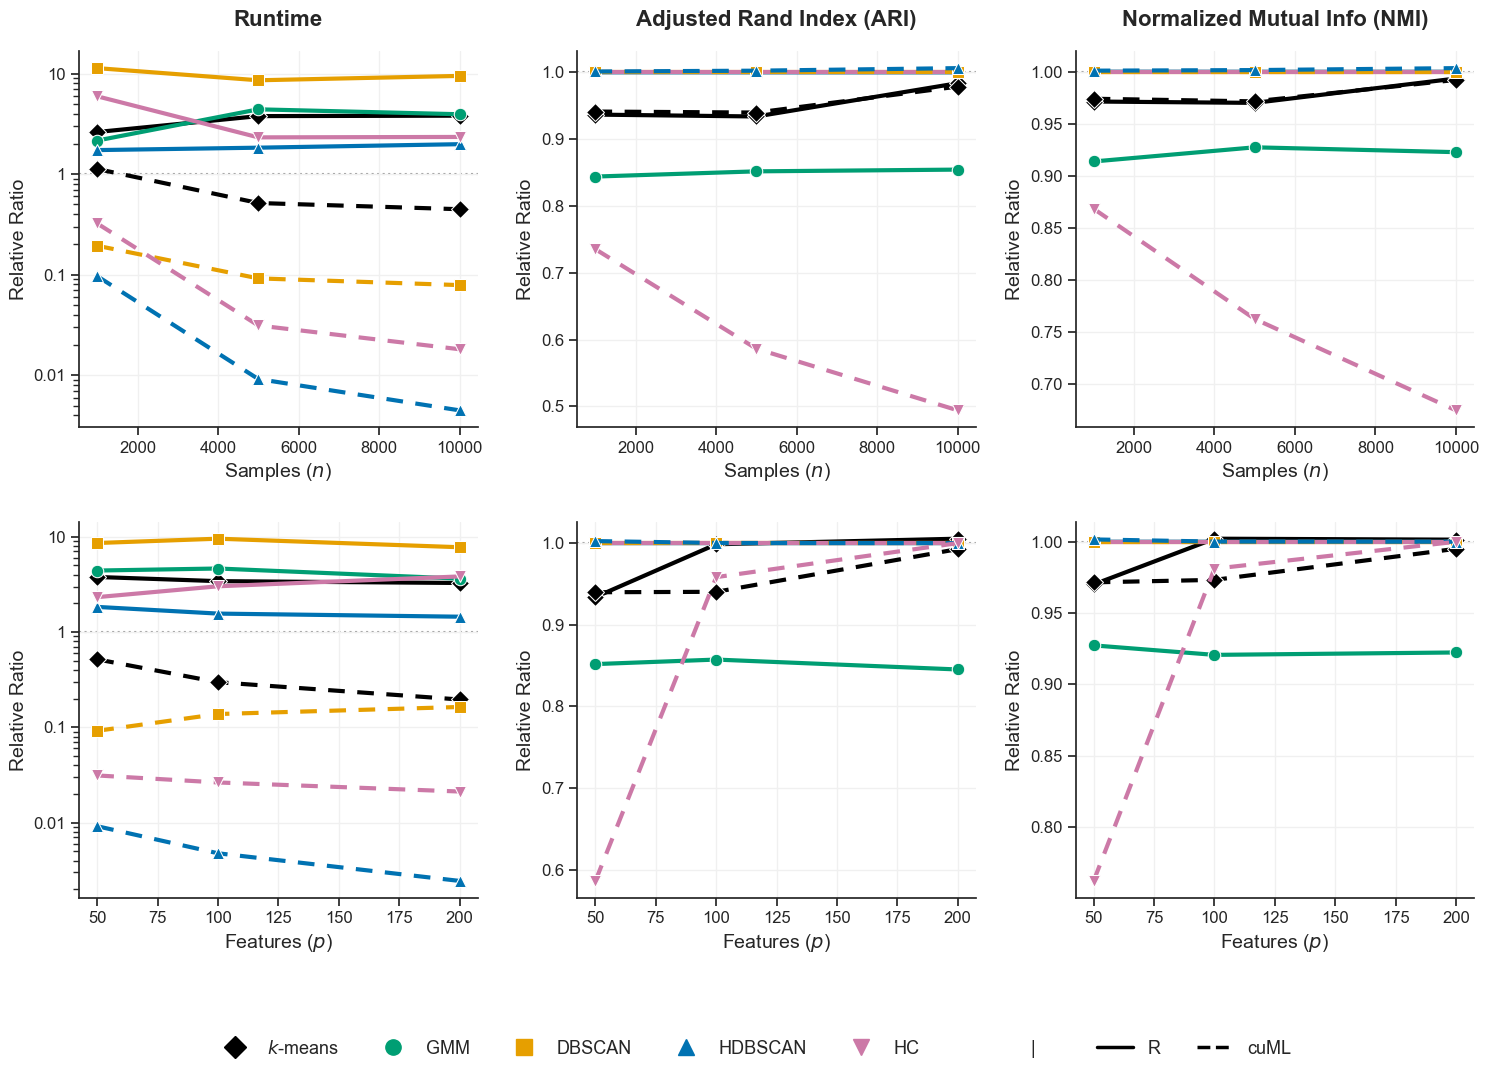

In [3]:
# Define the main function to generate the stylized ratio-based performance figures
def generate_ratio_figures(df, fixed_p=50, fixed_n=5000):
    # Define the list of performance metrics to be analyzed
    metrics = ['Runtime', 'ARI', 'NMI']
    
    # Calculate the mean for each metric, grouped by sample size, feature size, algorithm, and backend
    mean_df = df.groupby(['n', 'p', 'Algorithm', 'Backend'], as_index=False)[metrics].mean()
    
    # Extract a copy of the data specifically for the 'sklearn' backend to serve as the baseline
    ref_df = mean_df[mean_df['Backend'] == 'sklearn'].copy()
    
    # Create a dictionary mapping original metric names to new reference column names
    ref_cols = {m: f"{m}_ref" for m in metrics}
    
    # Rename the metric columns in the reference dataframe using the dictionary
    ref_df = ref_df.rename(columns=ref_cols)
    
    # Merge the reference metrics back into the main dataframe based on n, p, and Algorithm
    merged_df = pd.merge(mean_df, ref_df[['n', 'p', 'Algorithm'] + list(ref_cols.values())], on=['p', 'n', 'Algorithm'], how='left')
    
    # Iterate through each metric to calculate the ratio against the sklearn baseline
    for m in metrics:
        # Divide the current backend's metric value by the sklearn reference value
        merged_df[f"{m}_ratio"] = merged_df[m] / merged_df[f"{m}_ref"]
        
    # Create a plotting dataframe by dropping the sklearn baseline rows to clean up the plot
    plot_df = merged_df[merged_df['Backend'] != 'sklearn'].copy()
    # Select the original metrics, sklearn reference values, and calculated ratios
    # Create the non-sklearn dataframe used for ratio comparisons
    plot_df = merged_df[merged_df['Backend'] != 'sklearn'].copy()
    
    # Columns to report
    report_columns = [
        'n', 'p', 'Algorithm', 'Backend',
        'Runtime', 'Runtime_ref', 'Runtime_ratio',
        'ARI', 'ARI_ref', 'ARI_ratio',
        'NMI', 'NMI_ref', 'NMI_ratio'
    ]
        
    # Configure pandas display
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 200)

    # Define the specific order of algorithms for consistent coloring and plotting
    algorithms = ['KMEANS', 'GMM', 'DBSCAN', 'HDBSCAN', 'HC']
    # Convert the 'Algorithm' column to an ordered categorical type
    # Convert internal algorithm names to publication-ready display names
    algorithm_labels = {
        'KMEANS': 'k-means',
        'GMM': 'GMM',
        'DBSCAN': 'DBSCAN',
        'HDBSCAN': 'HDBSCAN',
        'HC': 'HC'
    }
    
    plot_df['Algorithm'] = plot_df['Algorithm'].replace(algorithm_labels)
    
    plot_df['Algorithm'] = pd.Categorical(
        plot_df['Algorithm'],
        categories=['k-means', 'GMM', 'DBSCAN', 'HDBSCAN', 'HC'],
        ordered=True
    )
    
    # Define the specific order of the target backends
    backends = ['R', 'cuML']
    # Convert the 'Backend' column to an ordered categorical type
    plot_df['Backend'] = pd.Categorical(plot_df['Backend'], categories=backends, ordered=True)
    
    # Filter the dataframe to get the subset where the number of features (p) is fixed
    df_varying_n = plot_df[plot_df['p'] == fixed_p]
    
    # Filter the dataframe to get the subset where the number of samples (n) is fixed
    df_varying_p = plot_df[plot_df['n'] == fixed_n]
    
    # Set the seaborn theme to use a white background with ticks
    sns.set_theme(style="ticks")
    # Define a colorblind-friendly palette containing 5 distinct colors for the algorithms
    palette = ['#000000', '#009e73', '#e69f00', '#0072b2', '#cc79a7']
    # Define 5 distinct marker styles for the algorithms
    markers = ['D', 'o', 's', '^', 'v']
    
    # INCREASED FIGSIZE: Change from (14, 8) to (18, 11) to make subplots significantly larger
    fig, axes = plt.subplots(2, 3, figsize=(18, 11), gridspec_kw={'hspace': 0.25, 'wspace': 0.25})
    
    # Generate the column names for the ratio metrics to plot on the y-axes
    ratio_metrics = [f"{m}_ratio" for m in metrics]
    
    # Define clean column titles to sit at the very top of each column
    col_titles = ['Runtime', 'Adjusted Rand Index (ARI)', 'Normalized Mutual Info (NMI)']
    
    # Define streamlined labels for the y-axes since the top title provides context
    y_label_names = {
        'Runtime_ratio': 'Relative Ratio',
        'ARI_ratio':     'Relative Ratio',
        'NMI_ratio':     'Relative Ratio'
    }
    
    # Define labels for the x-axes
    x_label_n = 'Samples ($n$)'
    x_label_p = 'Features ($p$)'
    
    # Define alphabetical labels for the subplots
    #subplot_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
    
    # Loop over the metrics to populate the first row of subplots (Varying n)
    for i, metric in enumerate(ratio_metrics):
        
        # Plot 'R' backend data exclusively with solid lines (dashes=False)
        sns.lineplot(data=df_varying_n[df_varying_n['Backend'] == 'R'], x='n', y=metric, 
                     hue='Algorithm', style='Algorithm',
                     palette=palette, markers=markers, dashes=False,
                     linewidth=3.0, markersize=9, legend=False, ax=axes[0, i])
        
        # Plot 'cuML' backend data exclusively with dashed lines
        sns.lineplot(data=df_varying_n[df_varying_n['Backend'] == 'cuML'], x='n', y=metric, 
                     hue='Algorithm', style='Algorithm',
                     palette=palette, markers=markers, dashes=[(4, 3)] * len(algorithms),
                     linewidth=3.0, markersize=9, legend=False, ax=axes[0, i])
        
        # INCREASED FONTSIZE: Column titles increased to 16
        axes[0, i].set_title(col_titles[i], fontsize=16, fontweight='bold', pad=18)
        # Draw a horizontal dotted gray line at y=1 to represent the sklearn reference baseline
        axes[0, i].axhline(y=1.0, color='gray', linestyle=':', alpha=0.8, zorder=0)
        # INCREASED FONTSIZE: X-axis labels increased to 14
        axes[0, i].set_xlabel(x_label_n, fontsize=14)
        # INCREASED FONTSIZE: Y-axis labels increased to 14
        axes[0, i].set_ylabel(y_label_names[metric], fontsize=14)
        
        # INCREASED TICK SIZE: Adjust the font size of the tick labels on both axes
        axes[0, i].tick_params(axis='both', which='major', labelsize=12)
        
        # Add the subplot letter and fixed p parameter at the top-left inside the plot
        #axes[0, i].text(0.04, 0.94, f'{subplot_labels[i]} $p={fixed_p}$', transform=axes[0, i].transAxes, fontsize=13, fontweight='bold', va='top')
        
        # Enable light gray gridlines for major ticks
        axes[0, i].grid(True, which='major', linestyle='-', color='#f0f0f0', zorder=0)
        
        # Apply logarithmic scaling to the y-axis if the metric is Runtime
        if 'Runtime' in metric:
            # Set y-axis scale to logarithmic
            axes[0, i].set_yscale('log')
            # Use scalar formatting to prevent scientific notation on the y-axis ticks
            axes[0, i].yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{y:g}'))
            
    # Loop over the metrics to populate the second row of subplots (Varying p)
    for i, metric in enumerate(ratio_metrics):
        
        # Plot 'R' backend data exclusively with solid lines (dashes=False)
        sns.lineplot(data=df_varying_p[df_varying_p['Backend'] == 'R'], x='p', y=metric, 
                     hue='Algorithm', style='Algorithm',
                     palette=palette, markers=markers, dashes=False,
                     linewidth=3.0, markersize=9, legend=False, ax=axes[1, i])
        
        # Plot 'cuML' backend data exclusively with dashed lines
        sns.lineplot(data=df_varying_p[df_varying_p['Backend'] == 'cuML'], x='p', y=metric, 
                     hue='Algorithm', style='Algorithm',
                     palette=palette, markers=markers, dashes=[(4, 3)] * len(algorithms),
                     linewidth=3.0, markersize=9, legend=False, ax=axes[1, i])
        
        # Draw a horizontal dotted gray line at y=1 to represent the sklearn reference baseline
        axes[1, i].axhline(y=1.0, color='gray', linestyle=':', alpha=0.8, zorder=0)
        # INCREASED FONTSIZE: X-axis labels increased to 14
        axes[1, i].set_xlabel(x_label_p, fontsize=14)
        # INCREASED FONTSIZE: Y-axis labels increased to 14
        axes[1, i].set_ylabel(y_label_names[metric], fontsize=14)
        
        # INCREASED TICK SIZE: Adjust the font size of the tick labels on both axes
        axes[1, i].tick_params(axis='both', which='major', labelsize=12)
        
        # Add the subplot letter and fixed n parameter at the top-left inside the plot
        #axes[1, i].text(0.04, 0.94, f'{subplot_labels[i+3]} $n={fixed_n}$', transform=axes[1, i].transAxes, fontsize=13, fontweight='bold', va='top')
        
        # Enable light gray gridlines for major ticks
        axes[1, i].grid(True, which='major', linestyle='-', color='#f0f0f0', zorder=0)
        
        # Apply logarithmic scaling to the y-axis if the metric is Runtime
        if 'Runtime' in metric:
            # Set y-axis scale to logarithmic
            axes[1, i].set_yscale('log')
            # Use scalar formatting to prevent scientific notation on the y-axis ticks
            axes[1, i].yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{y:g}'))
            
    # Remove the top and right spines from all subplots to create a cleaner look
    sns.despine()
    
    # Initialize an empty list to hold custom legend handle objects
    legend_handles = []
    algorithm_labels = [
        r'$k$-means',
        'GMM',
        'DBSCAN',
        'HDBSCAN',
        'HC'
    ]
    
    # Loop through the algorithms, assigning the corresponding color and marker to each
    for alg, color, marker in zip(algorithm_labels, palette, markers):
        # INCREASED MARKER SIZE for the legend items
        legend_handles.append(Line2D([0], [0], color=color, marker=marker, linestyle='None', markersize=11, label=alg))
        
    # Append a dummy handle containing just spaces to create a visual gap between algorithm and backend legends
    legend_handles.append(Line2D([0], [0], color='none', label='     |     '))
    
    # Create a custom solid black line handle to represent the R backend
    legend_handles.append(Line2D([0], [0], color='black', linestyle='-', linewidth=2.5, label='R'))
    # Create a custom dashed black line handle to represent the cuML backend
    legend_handles.append(Line2D([0], [0], color='black', linestyle='--', linewidth=2.5, label='cuML'))
    
    # Add the global legend to the figure, positioning it at the bottom center below the plots
    # INCREASED FONTSIZE: Legend text increased to 13
    fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=8, frameon=False, fontsize=13)
    
    # Apply tight layout to automatically adjust borders and prevent label overlapping
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    
    # Save the polished figure as a high-resolution PNG file suitable for publications
    plt.savefig('clustering_performance.png', dpi=300, bbox_inches='tight')
    
    # Render and display the final figure on the screen
    plt.show()
    
# Execute the main function using your predefined dataframe and fixed parameters
generate_ratio_figures(combined_df, fixed_p=50, fixed_n=5000)

In [6]:
def print_numbers(df, fixed_p=50, fixed_n=5000):
    """
    Calculate performance ratios relative to scikit-learn
    and print the numerical comparison tables.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe containing the following columns:
        n, p, Algorithm, Backend, Runtime, ARI, and NMI.

    fixed_p : int, default=50
        Fixed feature dimension for the varying-n comparison.

    fixed_n : int, default=5000
        Fixed sample size for the varying-p comparison.

    Returns
    -------
    dict
        A dictionary containing the processed dataframes.
    """

    # Define the performance metrics
    metrics = ['Runtime', 'ARI', 'NMI']

    # Calculate mean performance across replicates
    mean_df = (
        df.groupby(
            ['n', 'p', 'Algorithm', 'Backend'],
            as_index=False
        )[metrics]
        .mean()
    )

    # Extract scikit-learn results as the reference
    ref_df = mean_df[
        mean_df['Backend'] == 'sklearn'
    ].copy()

    # Rename the reference metric columns
    ref_cols = {
        metric: f'{metric}_ref'
        for metric in metrics
    }

    ref_df = ref_df.rename(columns=ref_cols)

    # Merge the scikit-learn reference values into all backend rows
    merged_df = pd.merge(
        mean_df,
        ref_df[
            ['n', 'p', 'Algorithm']
            + list(ref_cols.values())
        ],
        on=['n', 'p', 'Algorithm'],
        how='left'
    )

    # Calculate ratios relative to scikit-learn
    for metric in metrics:
        merged_df[f'{metric}_ratio'] = (
            merged_df[metric]
            / merged_df[f'{metric}_ref']
        )

    # Keep only non-reference backends
    comparison_df = merged_df[
        merged_df['Backend'] != 'sklearn'
    ].copy()

    # Define columns for the runtime comparison tables
    runtime_columns = [
        'n',
        'p',
        'Algorithm',
        'Backend',
        'Runtime',
        'Runtime_ref',
        'Runtime_ratio'
    ]

    # Define columns for the clustering accuracy tables
    accuracy_columns = [
        'n',
        'p',
        'Algorithm',
        'Backend',
        'ARI',
        'ARI_ref',
        'ARI_ratio',
        'NMI',
        'NMI_ref',
        'NMI_ratio'
    ]

    # Prepare runtime results for varying n at fixed p
    runtime_varying_n = (
        comparison_df[
            comparison_df['p'] == fixed_p
        ][runtime_columns]
        .sort_values(
            ['Algorithm', 'Backend', 'n']
        )
    )

    # Prepare runtime results for varying p at fixed n
    runtime_varying_p = (
        comparison_df[
            comparison_df['n'] == fixed_n
        ][runtime_columns]
        .sort_values(
            ['Algorithm', 'Backend', 'p']
        )
    )

    # Prepare accuracy results for varying n at fixed p
    accuracy_varying_n = (
        comparison_df[
            comparison_df['p'] == fixed_p
        ][accuracy_columns]
        .sort_values(
            ['Algorithm', 'Backend', 'n']
        )
    )

    # Prepare accuracy results for varying p at fixed n
    accuracy_varying_p = (
        comparison_df[
            comparison_df['n'] == fixed_n
        ][accuracy_columns]
        .sort_values(
            ['Algorithm', 'Backend', 'p']
        )
    )

    # Temporarily configure dataframe display settings
    with pd.option_context(
        'display.max_rows', None,
        'display.max_columns', None,
        'display.width', 220,
        'display.max_colwidth', None
    ):
        print(
            f'\n=== Runtime comparison: '
            f'varying n at p={fixed_p} ==='
        )

        print(
            runtime_varying_n
            .round(4)
            .to_string(index=False)
        )

        print(
            f'\n=== Runtime comparison: '
            f'varying p at n={fixed_n} ==='
        )

        print(
            runtime_varying_p
            .round(4)
            .to_string(index=False)
        )

        print(
            f'\n=== Clustering accuracy: '
            f'varying n at p={fixed_p} ==='
        )

        print(
            accuracy_varying_n
            .round(4)
            .to_string(index=False)
        )

        print(
            f'\n=== Clustering accuracy: '
            f'varying p at n={fixed_n} ==='
        )

        print(
            accuracy_varying_p
            .round(4)
            .to_string(index=False)
        )

    # Return the processed dataframes for optional later use
    return {
        'mean_df': mean_df,
        'merged_df': merged_df,
        'comparison_df': comparison_df,
        'runtime_varying_n': runtime_varying_n,
        'runtime_varying_p': runtime_varying_p,
        'accuracy_varying_n': accuracy_varying_n,
        'accuracy_varying_p': accuracy_varying_p
    }


# Run the function using the existing combined_df dataframe
results = print_numbers(
    combined_df,
    fixed_p=50,
    fixed_n=5000
)


=== Runtime comparison: varying n at p=50 ===
    n  p Algorithm Backend  Runtime  Runtime_ref  Runtime_ratio
 1000 50    DBSCAN       R   0.1053       0.0093        11.3348
 5000 50    DBSCAN       R   1.4901       0.1736         8.5828
10000 50    DBSCAN       R   6.6816       0.7042         9.4881
 1000 50    DBSCAN    cuML   0.0018       0.0093         0.1940
 5000 50    DBSCAN    cuML   0.0160       0.1736         0.0919
10000 50    DBSCAN    cuML   0.0555       0.7042         0.0788
 1000 50       GMM       R   0.0145       0.0067         2.1594
 5000 50       GMM       R   0.0887       0.0201         4.4131
10000 50       GMM       R   0.1560       0.0396         3.9433
 1000 50        HC       R   0.1346       0.0226         5.9465
 5000 50        HC       R   2.2197       0.9559         2.3221
10000 50        HC       R  10.0135       4.2705         2.3448
 1000 50        HC    cuML   0.0073       0.0226         0.3232
 5000 50        HC    cuML   0.0299       0.9559         